# Lesson 7: Creating figures

In this lesson, we will explore several ways to create figures in Python. We will primarily use matplotlib, the library for all things plotting in Python. We will only skim the surface of the types of plots that are possible with matplotlib. Charts aren't the only type of figures we might want to create - just as common we will want to create maps showing geographic features. For this, we will also use cartopy, which extends matplotlib into cartographic style plotting in which we can change coordinate reference systems, for example. 

When choosing the right type of figure for a given dataset or problem, you might find helpful the [Python graph gallery](https://python-graph-gallery.com/). However, creating figures is ultimately a subjective process reflecting your own style, so don't be afraid to explore the many plotting options provided by matplotlib beyond what we cover here.

### Learning outcomes

After this lesson, you should be able to:

1) Recall the general syntax for pyplot API and objected-oriented approaches to plot data in Python. 
2) Plot real data using different types of figures including line, scatter, and histograms.
3) Create multiple subplots figures using `plt.subplots()`.
4) Customize axes elements.
5) Apply cartopy to create map plots in various projection systems.

:::{danger}
## Entry ticket!
Before we start, discuss with your neighbor the concept you found the most challenging from the last lesson.
:::

## Figure and axes setup with matplotlib

There are quite a few different ways to create figures in Python. The most simple tends to involve using `plt.plot()` (known as the pyplot API). A slightly lengthier option that gives you more figure control is to use `fig, ax = plt.subplots()` (known as object-oriented API to plotting). Pandas DataFrames also have many built in plotting functions, as do Xarray DataArrays. Which method you choose is a matter of personal preference and your intended audience for the figure. 

Simple plotting routines allow us to visualize data quickly but aren't the prettist. On the other hand, more involved plotting routines take more time to set up but we can achive publication worthy results. It's really a balance of control and complexity versus time and ease of use. 

Read the matplotlib docs for example figures, cheatsheets, and tutorials: https://matplotlib.org/

In [1]:
import matplotlib.pyplot as plt

<class 'matplotlib.figure.Figure'>
<class 'matplotlib.axes._axes.Axes'>
Axes(0.125,0.11;0.775x0.77)


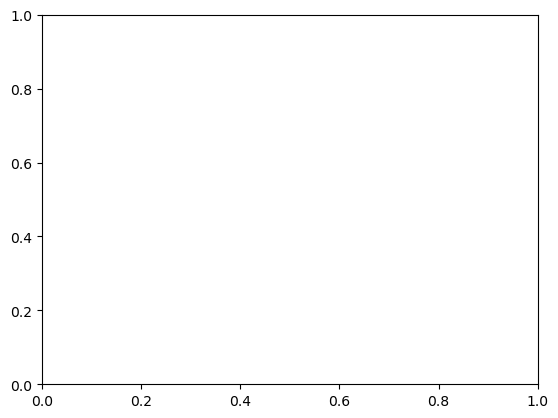

In [2]:
# Create figure and axes objects
fig = plt.figure()
ax = plt.axes()

print(type(fig))
print(type(ax))
print(ax)

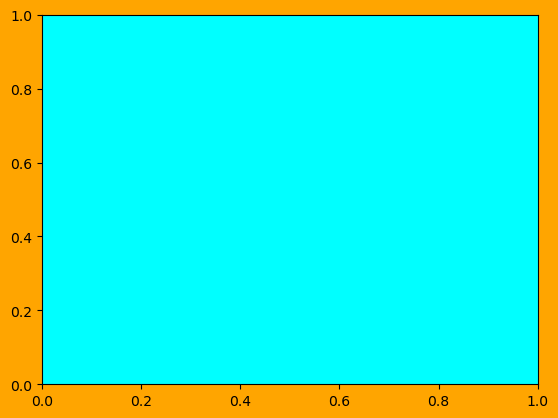

In [3]:
# Try commenting out either of the last two lines to see how the figure changes
fig = plt.figure()
ax = plt.axes()
fig.set_facecolor('orange')  # changing the color of the figure
ax.set_facecolor('cyan')  # changing the color of the axes

## Establishing axes with plt.subplots()

The way I tend to create figures is by first calling `fig, ax = plt.subplots()`. This matplotlib function can take various arguments including the number of rows and columns of axes we want to create, and the width and height of the overall figure. For this reason, it is flexible and gives a good level of control over each axis with a plot containing multiple subplots. Note that you can use it for a single axis too.

From now on in this lesson, we will use this object-oriented plot API style. But note that many of the plots can also be created more quickly in fewer lines of code (but with less control) using `plt.plot()` type functions.

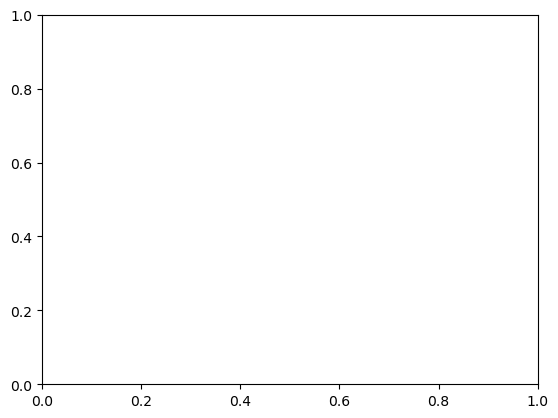

In [4]:
fig, ax = plt.subplots()

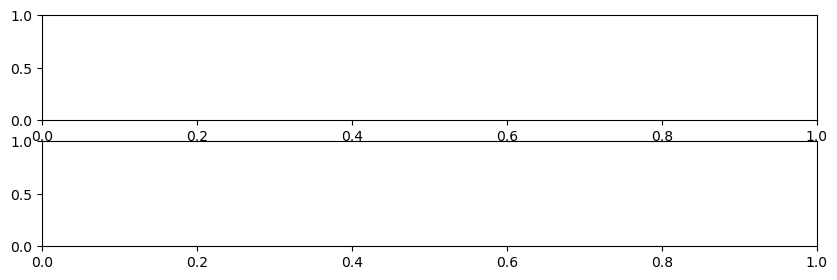

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(10,3))

In [6]:
# Look at the structure of the axes object now
# Think about how you would access each individual axis from it
axes

array([<Axes: >, <Axes: >], dtype=object)

:::{admonition}
### Exercise: Figure and axes setup

1. Create a figure containing three columns and four rows of axes.

2. Color all of the axes in the second row in red.

3. Hide the last axis. (Hint: ax.axis('off').|)

:::

<Axes: >

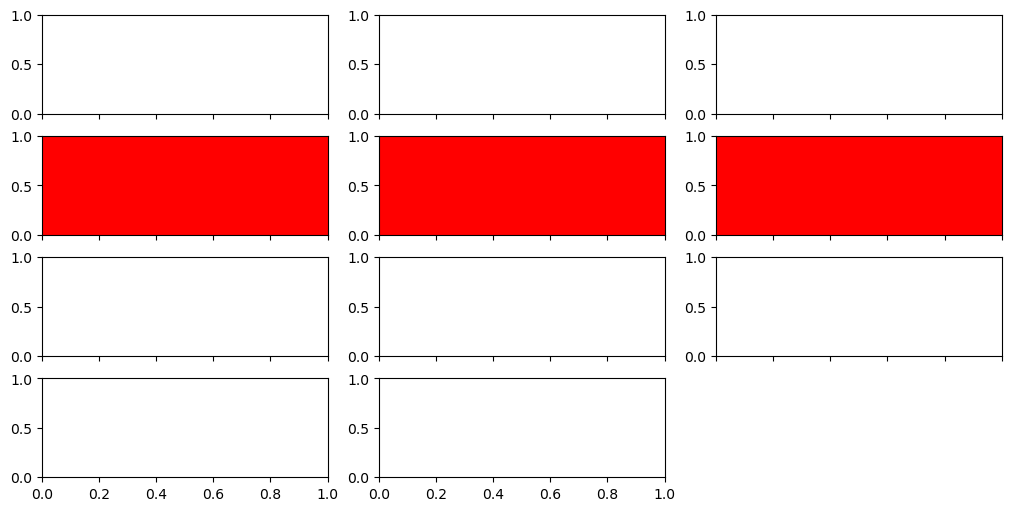

In [18]:
fig, axes = plt.subplots(4, 3, figsize=(10,5), constrained_layout=True,
                        sharex=True)
for ax in axes[1, :]:
    ax.set_facecolor('r')

axes[-1, -1].axis('off')

plt.show()

## Extra figure control and customization
When setting up your figure and axes with `plt.subplots()`, we are granted a good level of control over the figure and axes objects, but for some things we may need to specify that we want further control. Here are some additional customization options you might want to try out:

* `constrained_layout`: automatically constrain layout for tidy formatting.
* `sharex`, `sharey`: multiple axes can share either the x or y axes.
* `subplots_adjust`: manually adjust subplot spacing.
* `spines`: remove spines from an axes.
* `GridSpec`: take more control over the relative sizes of subplots.
* `inset_axes`: create small inset plots within an axes.
* `set_aspect`: control the aspect ratio of an axes (when using gridded/raster data).
* `zorder`: control the order in which plot items are rendered.
* `set_yscale('log')`: set the y axis to a log scale.

## Plotting real data

Let's load some data from the NAAMES campaign taken in November 2015.

In [19]:
# Import libraries
import pandas as pd
import numpy as np

# Import example data - flight from NAAMES campaign
naames = pd.read_csv('./data/naames-mrg01-c130_merge_20151112.csv')

# Remove NaN values
naames = naames.replace(-999999, np.nan)

# Trim the whitespace from column names
naames.columns = naames.columns.str.strip()

# Show all columns
print(naames.columns)

# Show first 5 rows
naames.head()

Index(['Fractional_Day', 'UTC', 'JDAY', 'INDEX', 'FLIGHT', 'LOCAL_SUN_TIME',
       'LATITUDE', 'LONGITUDE', 'ALTP', 'PRESSURE', 'TEMPERATURE', 'THETA',
       'O3COLUMN', 'SZA', 'WNS', 'WND', 'GPS_ALT', 'CO_MixingRatio_LARGE',
       'H2O_MixingRatio_LARGE', 'NOx_MixingRatio_LARGE', 'Org_LARGE',
       'SO4_LARGE', 'NO3_LARGE', 'NH4_LARGE', 'Chl_LARGE', 'BC_mass'],
      dtype='object')


,Fractional_Day,UTC,JDAY,INDEX,FLIGHT,LOCAL_SUN_TIME,LATITUDE,LONGITUDE,ALTP,PRESSURE,...,GPS_ALT,CO_MixingRatio_LARGE,H2O_MixingRatio_LARGE,NOx_MixingRatio_LARGE,Org_LARGE,SO4_LARGE,NO3_LARGE,NH4_LARGE,Chl_LARGE,BC_mass
0,316.46124,39851,316,100001,1,7.551806,47.623684,307.229179,0.098450,1001.45,...,0.1424,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,316.46125,39852,316,100002,1,7.552084,47.623684,307.229179,0.098755,1001.42,...,0.1424,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,316.46126,39853,316,100003,1,7.552362,47.623684,307.229179,0.099060,1001.38,...,0.1424,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,316.46127,39854,316,100004,1,7.552640,47.623684,307.229179,0.099365,1001.34,...,0.1424,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,316.46128,39855,316,100005,1,7.552918,47.623684,307.229179,0.099060,1001.40,...,0.1424,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Line plot

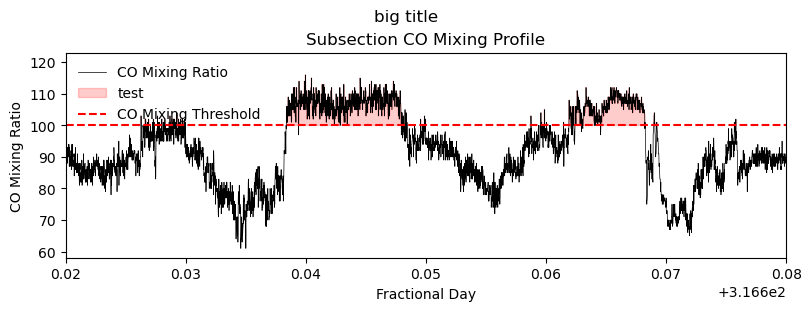

In [30]:
# Create a plot of CO mixing ratio against time
fig, ax = plt.subplots(figsize=(8,3), constrained_layout=True)

ax.plot(naames['Fractional_Day'], naames['CO_MixingRatio_LARGE'], 
        color='black', lw=0.5, label='CO Mixing Ratio')

# Title and axis labels
ax.set_title('Subsection CO Mixing Profile')
ax.set_xlabel('Fractional Day')   # adding a label on the x axis
ax.set_ylabel('CO Mixing Ratio') 

# # x and y limits
ax.set_xlim(316.62, 316.68)

# Altitude over 1
ax.fill_between(x=naames['Fractional_Day'], y1=naames['CO_MixingRatio_LARGE'], y2=100,
                where=naames['CO_MixingRatio_LARGE'] > 100, color='r', alpha=0.2, label='test')
ax.axhline(y=100, linestyle='--', color='r', label='CO Mixing Threshold')

# Add legend
ax.legend(loc='upper left', frameon=False)

fig.suptitle('big title')

plt.savefig('newfig.png', bbox_inches='tight')
plt.show()

### Scatter plot

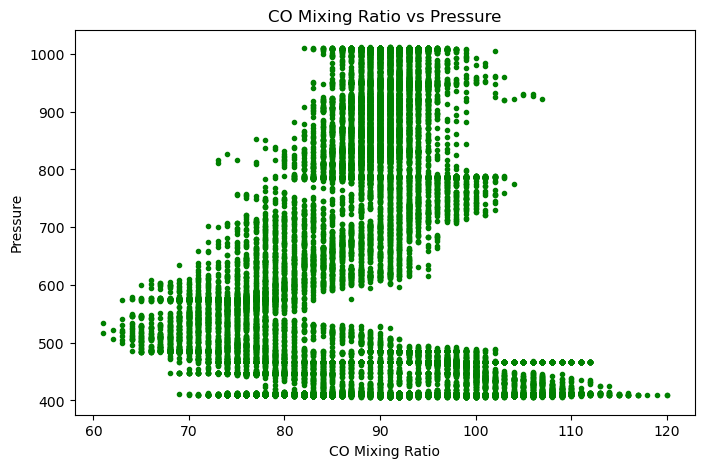

In [31]:
# Create a scatter plot of pressure against Co mixing ratio
fig, ax = plt.subplots(figsize=(8,5))

ax.scatter(naames['CO_MixingRatio_LARGE'], naames['PRESSURE'],
           marker='.', color='g')

# Title and axis labels
ax.set_title('CO Mixing Ratio vs Pressure')
ax.set_xlabel('CO Mixing Ratio') 
ax.set_ylabel('Pressure')   # adding a label on the x axis

plt.show()

### Histogram

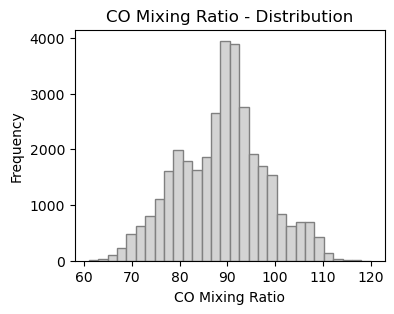

In [32]:
# Create a scatter plot of pressure against Co mixing ratio
fig, ax = plt.subplots(figsize=(4,3))

ax.hist(naames['CO_MixingRatio_LARGE'], bins=30,
        facecolor='lightgray', edgecolor='gray')

# Title and axis labels
ax.set_title('CO Mixing Ratio - Distribution')
ax.set_xlabel('CO Mixing Ratio')   # adding a label on the x axis
ax.set_ylabel('Frequency') 

plt.show()

:::{admonition}
### Exercise: Multiple subplots practice

Choose your own atmospheric variable from this dataset and **create a single figure containing a line plot, a scatter plot, and a histogram** of that variable. Here are some suggested variables you could use: 'O3COLUMN', 'SZA', 'WNS', 'H2O_MixingRatio_LARGE', 'NOx_MixingRatio_LARGE', 'Org_LARGE', 'SO4_LARGE', 'NO3_LARGE', 'NH4_LARGE', 'Chl_LARGE', 'BC_mass'.


1. Create a figure containing three columns of axes on a single row. You may wish to increase the width of the figure size.

2. In the first axis, plot a line plot of your chosen variable against Fractional Day.

3. In the second axis, plot a scatter plot of your chosen variable against Pressure.

4. In the third axis, plot a histogram of your chosen variable.

Remember to **give each axis an appropriate title and axis titles**. Finally, give the figure an appropriate overall figure title (hint: `fig.suptitle()`).

:::

:::{dropdown}

### Solution


```
# Create a plot of CO mixing ratio against time
fig, axes = plt.subplots(1, 3, figsize=(15,5), constrained_layout=True)

# Line plot
ax=axes[0]
ax.plot(naames['Fractional_Day'], naames['CO_MixingRatio_LARGE'], 
        color='black', lw=0.5, label='CO Mixing Ratio')
ax.set_title('Subsection CO Mixing Profile')
ax.set_xlabel('Fractional Day')   # adding a label on the x axis
ax.set_ylabel('CO Mixing Ratio') 


# Scatter plot
ax=axes[1]
ax.scatter(naames['CO_MixingRatio_LARGE'], naames['PRESSURE'],
           marker='.', color='black')
ax.set_title('CO Mixing Ratio vs Pressure')
ax.set_xlabel('CO Mixing Ratio') 
ax.set_ylabel('Pressure')   # adding a label on the x axis

# Histogram
ax=axes[2]
ax.hist(naames['CO_MixingRatio_LARGE'], bins=30,
        facecolor='gray', edgecolor='k')
ax.set_title('CO Mixing Ratio - Distribution')
ax.set_xlabel('CO Mixing Ratio')   # adding a label on the x axis
ax.set_ylabel('Frequency') 

# Figure title
fig.suptitle('CO Mixing Ratio - NAAMES Flight 2015-11-12')

plt.show()
```

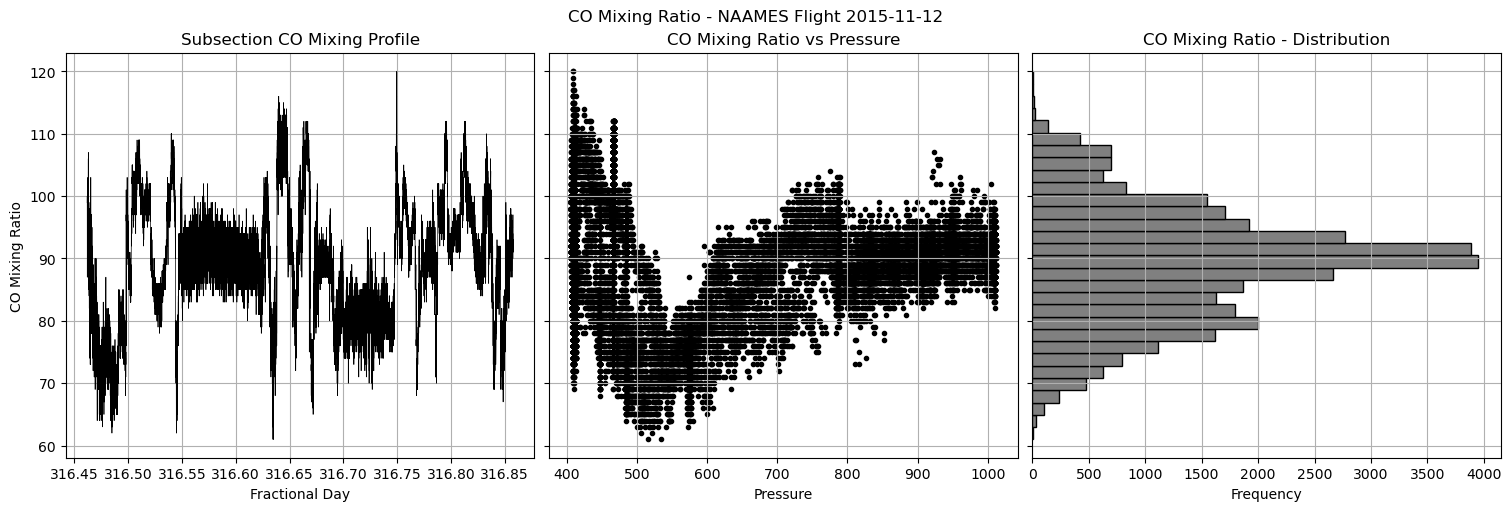

In [36]:
# Create a plot of CO mixing ratio against time
fig, axes = plt.subplots(1, 3, figsize=(15,5), constrained_layout=True, sharey=True)

# Line plot
ax=axes[0]
ax.plot(naames['Fractional_Day'], naames['CO_MixingRatio_LARGE'], 
        color='black', lw=0.5, label='CO Mixing Ratio')
ax.set_title('Subsection CO Mixing Profile')
ax.set_xlabel('Fractional Day')   # adding a label on the x axis
ax.set_ylabel('CO Mixing Ratio') 


# Scatter plot
ax=axes[1]
ax.scatter(naames['PRESSURE'], naames['CO_MixingRatio_LARGE'], 
           marker='.', color='black')
ax.set_title('CO Mixing Ratio vs Pressure')
# ax.set_ylabel('CO Mixing Ratio') 
ax.set_xlabel('Pressure')   # adding a label on the x axis

# Histogram
ax=axes[2]
ax.hist(naames['CO_MixingRatio_LARGE'], bins=30,
        facecolor='gray', edgecolor='k', orientation='horizontal')
ax.set_title('CO Mixing Ratio - Distribution')
# ax.set_ylabel('CO Mixing Ratio')   # adding a label on the x axis
ax.set_xlabel('Frequency') 

# Figure title
fig.suptitle('CO Mixing Ratio - NAAMES Flight 2015-11-12')

for ax in axes:
    ax.grid('on')

plt.show()

## Plotting maps with cartopy

Cartopy extend matplotlib to make cartographic map plots. While geodataframes can be plot spatially using geopandas, cartopy allows you to do extra things like plot your spatial data in a different coordinate reference system, or have explicit control on spatial coordinate limits and grid lines formatting.

In [37]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

In [42]:
# Open the SST dataset and convert to data array
sst_ds = xr.open_dataset('./data/oisst-avhrr-v02r01.20220304.nc')
sst = sst_ds.sst.isel(zlev=0).isel(time=0)

# Preprocessing - convert longitude to -180 -> 180 degrees
sst['lon'] = (sst['lon'] + 180) % 360 - 180
sst = sst.sortby(sst.lon)

# Select a smaller subset area
sst = sst.sel(lon=slice(-180, -120), lat=slice(40, 75))

sst

<xarray.DataArray 'sst' (lat: 140, lon: 240)> Size: 134kB
[33600 values with dtype=float32]
Coordinates:
  * lat      (lat) float32 560B 40.12 40.38 40.62 40.88 ... 74.38 74.62 74.88
  * lon      (lon) float32 960B -179.9 -179.6 -179.4 ... -120.6 -120.4 -120.1
    time     datetime64[ns] 8B 2022-03-04T12:00:00
    zlev     float32 4B 0.0
Attributes:
    long_name:  Daily sea surface temperature
    units:      Celsius
    valid_min:  -300
    valid_max:  4500

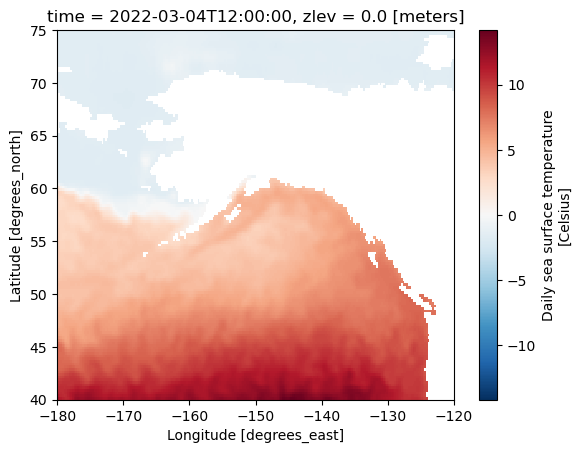

In [43]:
# Default xarray plotting
sst.plot()

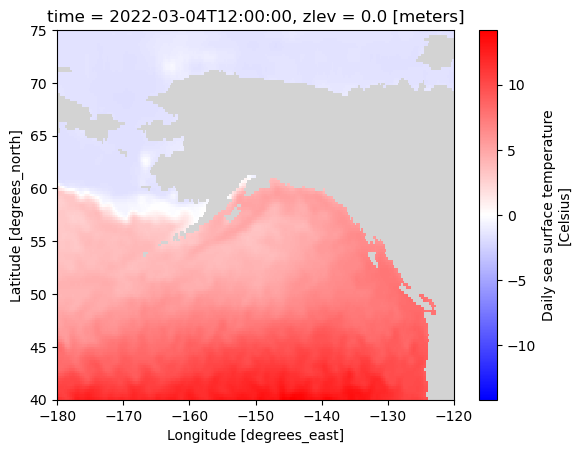

In [44]:
# Extract the colormap and set the "bad" color to gray for no data areas
bwr_badgrey = plt.get_cmap("bwr").copy()
bwr_badgrey.set_bad('lightgray')
# bwr_badgrey.set_bad('#c0c0c0')

# Plot with cmap and custom bad color
sst.plot(cmap=bwr_badgrey)

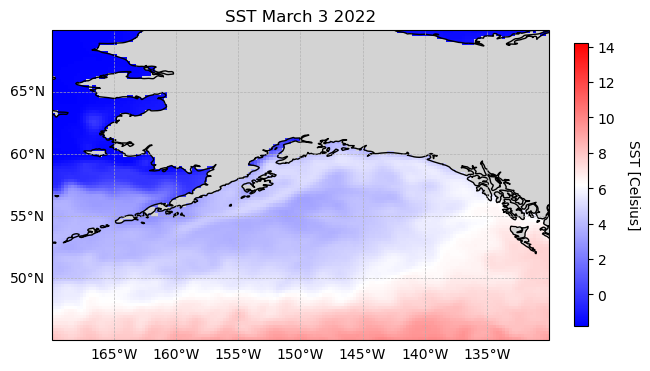

In [45]:
# Let's add in cartopy functionality!

# Set the projection. PlateCarree is "regular" lat/lon
map_proj = ccrs.PlateCarree()
data_proj = ccrs.PlateCarree()

# Create plot
fig, ax = plt.subplots(subplot_kw={'projection':map_proj},
                       constrained_layout=True)

# Add the data to the plot
pc = ax.pcolormesh(sst.lon, sst.lat, sst, transform=data_proj, cmap=bwr_badgrey)

# Add gridlines
gl = ax.gridlines(draw_labels=True, linewidth=0.5, linestyle='--', alpha=0.9)
gl.top_labels, gl.right_labels = False, False  # remove top and right grid line labels

# Add the colorbar
cb = fig.colorbar(pc, extend='neither', shrink=0.6)
cb.set_label('SST [Celsius]', rotation=270, labelpad=18)

# Add a title
ax.set_title('SST March 3 2022')

# Ax.set_extent can be used to control the axes limits when using cartopy
# [xmin, xmax, ymin, ymax]
ax.set_extent([-170, -130, 45, 70], crs=data_proj)

# Add coastlines
ax.coastlines()

## Transforming the map to another projection

Alaska is pretty far north, so we may want to use a map projection that is more accurate for that region. Looking through the [cartopy projection list](https://scitools.org.uk/cartopy/docs/v0.15/crs/projections.html) it looks like an Albers Equal Area projection minimizes distortion in northern latitudes, so let's use that one.

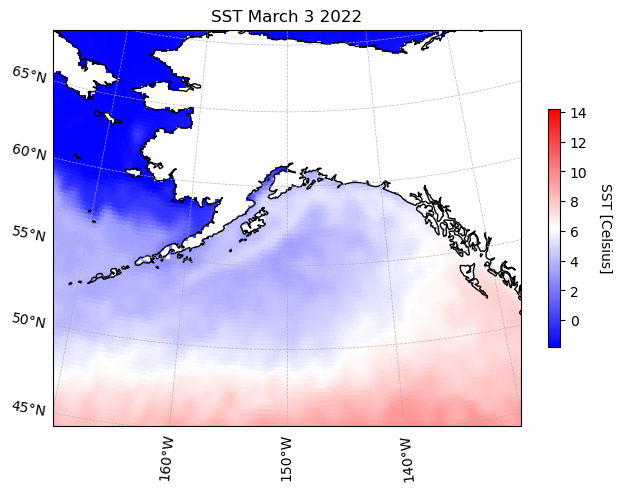

In [46]:
# Define a new map projection
map_proj = ccrs.AlbersEqualArea(central_longitude=-150)
data_proj = ccrs.PlateCarree()

# Create plot
fig, ax = plt.subplots(subplot_kw={'projection':map_proj},
                       constrained_layout=True)

# Add the data to the plot
pc = ax.pcolormesh(sst.lon, sst.lat, sst, transform=data_proj, cmap='bwr')

# Add gridlines
gl = ax.gridlines(draw_labels=True, linewidth=0.5, linestyle='--', alpha=0.9)
gl.top_labels, gl.right_labels = False, False  

# Make the axes ticks inside and large 
ax.tick_params(axis='both', direction='in', length=10)

# Add the colorbar
cb = fig.colorbar(pc, extend='neither', shrink=0.6)
cb.set_label('SST [Celsius]', rotation=270, labelpad=18)

# Add a title
ax.set_title('SST March 3 2022')

# Ax.set_extent can be used to control the axes limits when using cartopy
# [xmin, xmax, ymin, ymax]
ax.set_extent([-170, -130, 45, 70], crs=data_proj)

# Add coastlines
ax.coastlines()

:::{admonition}
### Exercise: Creating a map with cartopy 

Using the NASA SRTM elevation raster data and counties shapefile data for Colorado provided below:

1. Subset the data to a smaller area of your choice using `sel` or `isel` combined with `slice()`.

2. Create a map plot of the elevation data using cartopy and an appropriate colormap (https://matplotlib.org/stable/users/explain/colors/colormaps.html). Use the Miller projection with the central longitude at the center of your subsetted data region (see available projections at https://scitools.org.uk/cartopy/docs/v0.15/crs/projections.html).

3. Add the Colorado counties to your map (hint: `ax.add_geometries(gdf.geometry)`) with blank fill color (hint: `facecolor='none'`).

:::

In [47]:
import xarray as xr
import geopandas as gpd

# Open the SRTM elevation data for Colorado
srtm = xr.open_dataset('data/SRTMGL3_CO.tif')['band_data'].squeeze()
srtm = srtm.sortby(srtm.y)
print('CRS:', srtm.rio.crs.to_epsg())
srtm

CRS: 4326


<xarray.DataArray 'band_data' (y: 1705, x: 2925)> Size: 20MB
[4987125 values with dtype=float32]
Coordinates:
  * y            (y) float64 14kB 36.83 36.83 36.84 36.84 ... 41.09 41.09 41.09
  * x            (x) float64 23kB -109.2 -109.2 -109.2 ... -101.9 -101.9 -101.9
    band         int64 8B 1
    spatial_ref  int64 8B ...
Attributes:
    AREA_OR_POINT:  Area
    long_name:      band_data

In [48]:
# Open the Colorado counties geojson as geodataframe
co_counties = gpd.read_file('data/CO_counties.geojson')
print('CRS:', co_counties.crs)
co_counties.head(2)

CRS: EPSG:4326


,id,STATEFP,COUNTYFP,COUNTYNS,GEOID,NAME,NAMELSAD,LSAD,CLASSFP,MTFCC,CSAFP,CBSAFP,METDIVFP,FUNCSTAT,ALAND,AWATER,INTPTLAT,INTPTLON,geometry
0,tl_2019_08_county.1,08,109,00198170,08109,Saguache,Saguache County,06,H1,G4020,,,,A,8206547705,4454510,+38.0316514,-106.2346662,"MULTIPOLYGON (((-106.8714 37.94189, -106.87199..."
1,tl_2019_08_county.2,08,115,00198173,08115,Sedgwick,Sedgwick County,06,H1,G4020,,,,A,1419419016,3530746,+40.8715679,-102.3553579,"MULTIPOLYGON (((-102.65211 40.88463, -102.6521..."


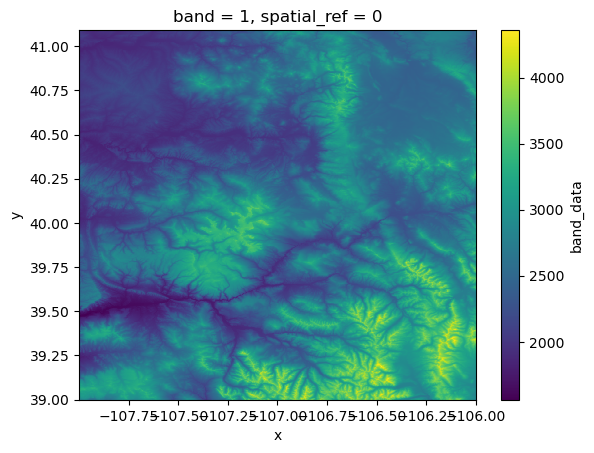

In [51]:
srtm_sub = srtm.sel(x=slice(-108, -106), y=slice(39, 42))
srtm_sub.plot()

# Use the data to determine central longitude
central_lon = srtm_sub.x.mean().item()

# Define a new map projection
map_proj = ccrs.Miller(central_longitude=central_lon)
data_proj = ccrs.PlateCarree()

# Create plot
fig, ax = plt.subplots(subplot_kw={'projection':map_proj},
                       constrained_layout=True)

:::{dropdown}

### Solution


```
# Take subset of data between 39-42 N, 106-108 W
srtm_sub = srtm.sel(x=slice(-108, -106), y=slice(39, 42))

# Use the data to determine central longitude
central_lon = srtm_sub.x.mean().item()

# Define a new map projection
map_proj = ccrs.Miller(central_longitude=central_lon)
data_proj = ccrs.PlateCarree()

# Create plot
fig, ax = plt.subplots(subplot_kw={'projection':map_proj},
                       constrained_layout=True)

# Add the data to the plot
pc = ax.pcolormesh(srtm_sub.x, srtm_sub.y, srtm_sub, transform=data_proj, cmap='terrain')

# Add gridlines
gl = ax.gridlines(draw_labels=True, linewidth=0.5, linestyle='--', alpha=0.9)
gl.top_labels, gl.right_labels = False, False  

# Add the colorbar
cb = fig.colorbar(pc, extend='neither', shrink=0.8)
cb.set_label('Elevation (ft)', rotation=270, labelpad=18)

# Add a title
ax.set_title('SRTM Elevation for Central Colorado')

# Add Colorado counties
ax.add_geometries(co_counties.geometry, crs=data_proj,
                  facecolor='none', edgecolor='w')

plt.show()
```

:::{danger}
## Exit ticket!

Before you leave this lesson, please [submit your responses here](https://forms.gle/cVjyNwBZyUycm6RT6) to three quick questions: 

* How much of this lesson's content do you feel comfortable with? 0-10, with 10 being all of the content.
* How was the pace of this lesson for you? 1) Too slow; 2) About right; 3) Too fast.
* In a few words or less, what single concept was most challenging for you in this lesson?

:::

:::{hint}
## Bonus concept: other plotting libraries

In this lesson, we used matplotlib and cartopy as our plotting libraries. There are some other libraries available for specific types of plotting:

* [**seaborn**](https://seaborn.pydata.org/): create pretty plots and perform some more complex figure types easy in a few lines of code, but somewhat takes away some of the control compared to when using matplotlib. See examples in SARP programming [lesson 5.2](https://nasa-sarp.github.io/sarp_lessons/sarp_lessons/1_python_progression/5-visualization/5-2_building_on_matplotlib.html).

* [**bokeh**](https://bokeh.org/): create interactive plots. See examples in SARP programming [lesson 5.3](https://nasa-sarp.github.io/sarp_lessons/sarp_lessons/1_python_progression/5-visualization/5-3_dynamic_visualization.html).

  
* [**leaflet**](https://ipyleaflet.readthedocs.io/en/latest/): create interactive map plots including various basemaps.

:::{hint}
## Further reading

* [SARP visualization gallery](https://nasa-sarp.github.io/sarp_lessons/sarp_lessons/5_example_gallery/index.html)
* [matplotlib beginnner cheatsheet](https://matplotlib.org/cheatsheets/handout-beginner.pdf)
* [matplotlib intermediate cheatsheet](https://matplotlib.org/cheatsheets/handout-intermediate.pdf)
* [matplotlib pyplot demo](https://matplotlib.org/stable/gallery/subplots_axes_and_figures/subplots_demo.html)
* [matplotlib GridSpec demo](https://matplotlib.org/3.5.0/tutorials/intermediate/gridspec.html)
* [Python graph gallery](https://python-graph-gallery.com/)

:::